# Imports

In [358]:
from scipy.io import loadmat
from scipy.stats import mode
import numpy as np
import matplotlib.pyplot as plt
import os
from joblib import Parallel, delayed
import mne
from scipy.signal import butter, filtfilt, find_peaks, decimate

# Functions

### PSD

In [359]:
def psd_multitaper(lfp_data, fs, frequency_band, window_length):
    all_power_sum = []

    # loop through each segment
    for start in range(0, len(lfp_data) - window_length + 1, window_length):
        window = lfp_data[start:min(start + window_length, len(lfp_data))]

        # compute power spectral density using multitaper method
        psd, freqs = mne.time_frequency.psd_array_multitaper(window, fs, fmin=frequency_band[0], fmax=frequency_band[1], n_jobs=1, verbose = 'warning')

        # compute total power within frequency band
        freq_indices = (freqs >= frequency_band[0]) & (freqs <= frequency_band[1])
        curr_sum = np.sum(psd)
        all_power_sum.append(curr_sum)

    return all_power_sum

### Normalization

In [360]:
def wei_normalizing(data):
  data = np.array(data)

  bottom = data[data <= np.nanpercentile(data, 10, axis=0) ]
  bottom_avg = np.average(bottom)
  top = data[data >= np.nanpercentile(data, 90, axis=0) ]
  top_avg = np.average(top)
  normalized_data = (data - bottom_avg) / (top_avg - bottom_avg)  # Normalise with [min,max] -> [0,1]
  normalized_data = np.clip(normalized_data, 0.05, 1) # set to 0.05 all negative values, set to 1 all values greater than 1

  return normalized_data

### Index calculations

In [361]:
def index_W(theta, gamma, EMG):
  index_w = np.array([])
  for i in range(len(theta)):
    value = EMG[i]*EMG[i]*((gamma[i])/(theta[i]))
    index_w = np.append(index_w, [value])
  return index_w

In [362]:
def index_R(delta, theta, EMG, gamma):
  nindex_r = np.array([])
  for i in range(len(delta)):
    value = ((theta[i]*2)*gamma[i])/(delta[i]*delta[i]*EMG[i]**2)
    nindex_r = np.append(nindex_r, [value])
  return nindex_r

In [363]:
def index_N(delta, sigma, gamma):
  index_n = np.array([])
  for i in range(len(delta)):
    value = (delta[i]*sigma[i])/(gamma[i]**2)
    index_n = np.append(index_n, [value])
  return index_n

In [364]:
def Index_1(delta, gamma, EMG):
  index_1 = np.array([])
  for i in range(len(delta)):
    value = (EMG[i]*gamma[i])/(delta[i])
    index_1 = np.append(index_1, [value])
  return index_1

In [365]:
def Index_2(delta, theta, sigma):
  index_2 = np.array([])
  for i in range(len(delta)):
    value = (sigma[i]*delta[i])/(theta[i])
    index_2 = np.append(index_2, [value])
  return index_2

In [366]:
def Index_3(delta, theta, gamma):
  index_3 = np.array([])
  for i in range(len(delta)):
    value = (theta[i]*gamma[i])/(delta[i])
    index_3 = np.append(index_3, [value])
  return index_3

In [367]:
def Index_4(delta, theta):
  index_4 = np.array([])
  for i in range(len(delta)):
    value = delta[i]/theta[i]
    index_4 = np.append(index_4, [value])
  return index_4

### EOG auto correlation

In [368]:
def auto_correlation_slope(EOG, epoch_length, fs, min_slope_idx=1):
    samples = int(epoch_length * fs)
    slopes = []
    for i in range(0, len(EOG) - len(EOG) % samples, samples):
        epoch = EOG[i:i + samples]
        ac_full = np.correlate(epoch, epoch, mode='full')
        center = len(ac_full) // 2
        ac = ac_full[center:]  # non-negative lags
        # normalize ac so ac[0] == 1 (helps numeric stability)
        if ac[0] == 0:
            slopes.append(np.nan)
            continue
        ac = ac / ac[0]
        peaks, _ = find_peaks(ac)
        # find first peak with index >= min_slope_idx
        valid_peaks = [p for p in peaks if p >= min_slope_idx]
        if len(valid_peaks) < 1:
            slopes.append(np.nan)
            continue
        first_peak_idx = valid_peaks[0]
        # slope between lag 0 and first_peak_idx
        slope = (ac[first_peak_idx] - ac[0]) / first_peak_idx
        slopes.append(slope)
    return np.array(slopes)

# Variables

In [369]:
# # adjusted Frequency bands
noise_band = [0,0.5]
delta_band = [0.5,4]
theta_band = [5,8]
sigma_band = [12,16]
beta_band = [13,30]
gamma_band = [31,45]
total_band = [0,30]

In [370]:
subject = 'SC4042'
input_path = r"C:\Users\andri\school\bio-informatics\internship\donders\data\human_test_data\pre_processing\mat_files\improved_old_dataset\test"
fs = 100
epoch_length = 10
window_length = epoch_length * fs

# Load data

In [371]:
pz_data = loadmat(os.path.join(input_path, f'{subject}_Pz-Oz.mat'))
pz_data = pz_data['Pz-Oz']
raw_pz = np.ravel(pz_data)
print(len(raw_pz))

fpz_data = loadmat(os.path.join(input_path, f'{subject}_Fpz-Cz.mat'))
fpz_data = fpz_data['Fpz-Cz']
raw_fpz = np.ravel(fpz_data)
print(len(raw_fpz))

emg_data = loadmat(os.path.join(input_path, f'{subject}_EMG.mat'))
emg_data = emg_data['EMG']
raw_emg = np.ravel(emg_data)
print(len(raw_emg))

eog_data = loadmat(os.path.join(input_path, f'{subject}_EOG.mat'))
eog_data = next(v for k, v in eog_data.items() if 'EOG' in k)
raw_eog = np.ravel(eog_data)
print(len(raw_eog))

sleep_scoring = loadmat(os.path.join(input_path, f'{subject}_states.mat'))
states = sleep_scoring['states']
states = np.ravel(states)
print(len(states))

3612001
3612001
3612001
3612001
3612001


### EMG, EOG and states to epochs

In [372]:
emg_data = raw_emg[:len(raw_emg) // (epoch_length * fs) * (epoch_length*fs)]
emg_data = emg_data.reshape(-1, (epoch_length * fs))
emg_data = emg_data.sum(axis=1)
print(len(emg_data))

eog_data = raw_eog[:len(raw_eog) // (epoch_length * fs) * (epoch_length*fs)]
eog_data = eog_data.reshape(-1, (epoch_length * fs))
eog_data = eog_data.sum(axis=1)
print(len(eog_data))

sleep_scoring = np.array(states, dtype=int)
reshaped_scores = sleep_scoring[:len(sleep_scoring) // (epoch_length*fs) * (epoch_length*fs)].reshape(-1, epoch_length*fs)
majority_scores = mode(reshaped_scores, axis=1).mode.flatten()
print(len(majority_scores))

3612
3612
3612


# Main

### Power calculation

In [373]:
# raws = [np.ravel(raw_fpz), np.ravel(raw_fpz), np.ravel(raw_fpz), np.ravel(raw_fpz), np.ravel(raw_pz), np.ravel(raw_pz)]
# fr_bands = [noise_band, delta_band, theta_band, sigma_band, beta_band, gamma_band]

# noise, delta, theta, sigma, beta, gamma = Parallel(n_jobs=6)(delayed(psd_multitaper)(raw, fs, band, window_length) for raw, band in zip(raws, fr_bands))

### Normalize powers

In [374]:

# noise_norm = wei_normalizing(noise)
# delta_norm = wei_normalizing(delta)
# theta_norm = wei_normalizing(theta)
# sigma_norm = wei_normalizing(sigma)
# beta_norm = wei_normalizing(beta)
# gamma_norm = wei_normalizing(gamma)
# emg_norm = wei_normalizing(emg_data)
eog_norm = wei_normalizing(eog_data)


### Smoothing EMG and EOG

In [375]:
# emg_smoothed = np.convolve(np.convolve(np.convolve(emg_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
# eog_smoothed = np.convolve(eog_norm, np.ones(5)/5, mode='same')

### Calculating indices

In [376]:
# index_w = index_W(delta_norm, gamma_norm, emg_smoothed)
# index_n = index_N(delta_norm, sigma_norm, gamma_norm)
# index_r = index_R(delta_norm, theta_norm, sigma_norm, emg_smoothed)
# index_1 = Index_1(delta_norm, gamma_norm, emg_smoothed)
# index_2 = Index_2(delta_norm, theta_norm, sigma_norm)
# index_3 = Index_3(delta_norm, theta_norm, gamma_norm)
# index_4 = Index_4(delta_norm, theta_norm)

### Take log of indices

In [377]:
# index_w_log = np.log(index_w)
# index_n_log = np.log(index_n)
# index_r_log = np.log(index_r)
# index_1_log = np.log(index_1)
# index_2_log = np.log(index_2)
# index_3_log = np.log(index_3)
# index_4_log = np.log(index_4)

### Normalizing indices

In [378]:
# index_w_norm = wei_normalizing(index_w_log)
# index_n_norm = wei_normalizing(index_n_log)
# index_r_norm = wei_normalizing(index_r_log)
# index_1_norm = wei_normalizing(index_1_log)
# index_2_norm = wei_normalizing(index_2_log)
# index_3_norm = wei_normalizing(index_3_log)
# index_4_norm = wei_normalizing(index_4_log)

### Smoothing features

In [379]:
# index_w_smoothed = np.convolve(np.convolve(np.convolve(index_w_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
# index_n_smoothed = np.convolve(np.convolve(np.convolve(index_n_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
# index_r_smoothed = np.convolve(np.convolve(np.convolve(index_r_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
# index_1_smoothed = np.convolve(np.convolve(np.convolve(index_1_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
# index_2_smoothed = np.convolve(np.convolve(np.convolve(index_2_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
# index_3_smoothed = np.convolve(np.convolve(np.convolve(index_3_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
# index_4_smoothed = np.convolve(np.convolve(np.convolve(index_4_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

### Visualize raw eog

C:\Users\andri\AppData\Local\Temp\ipykernel_13636\3551563328.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
C:\Users\andri\AppData\Local\Temp\ipykernel_13636\3551563328.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


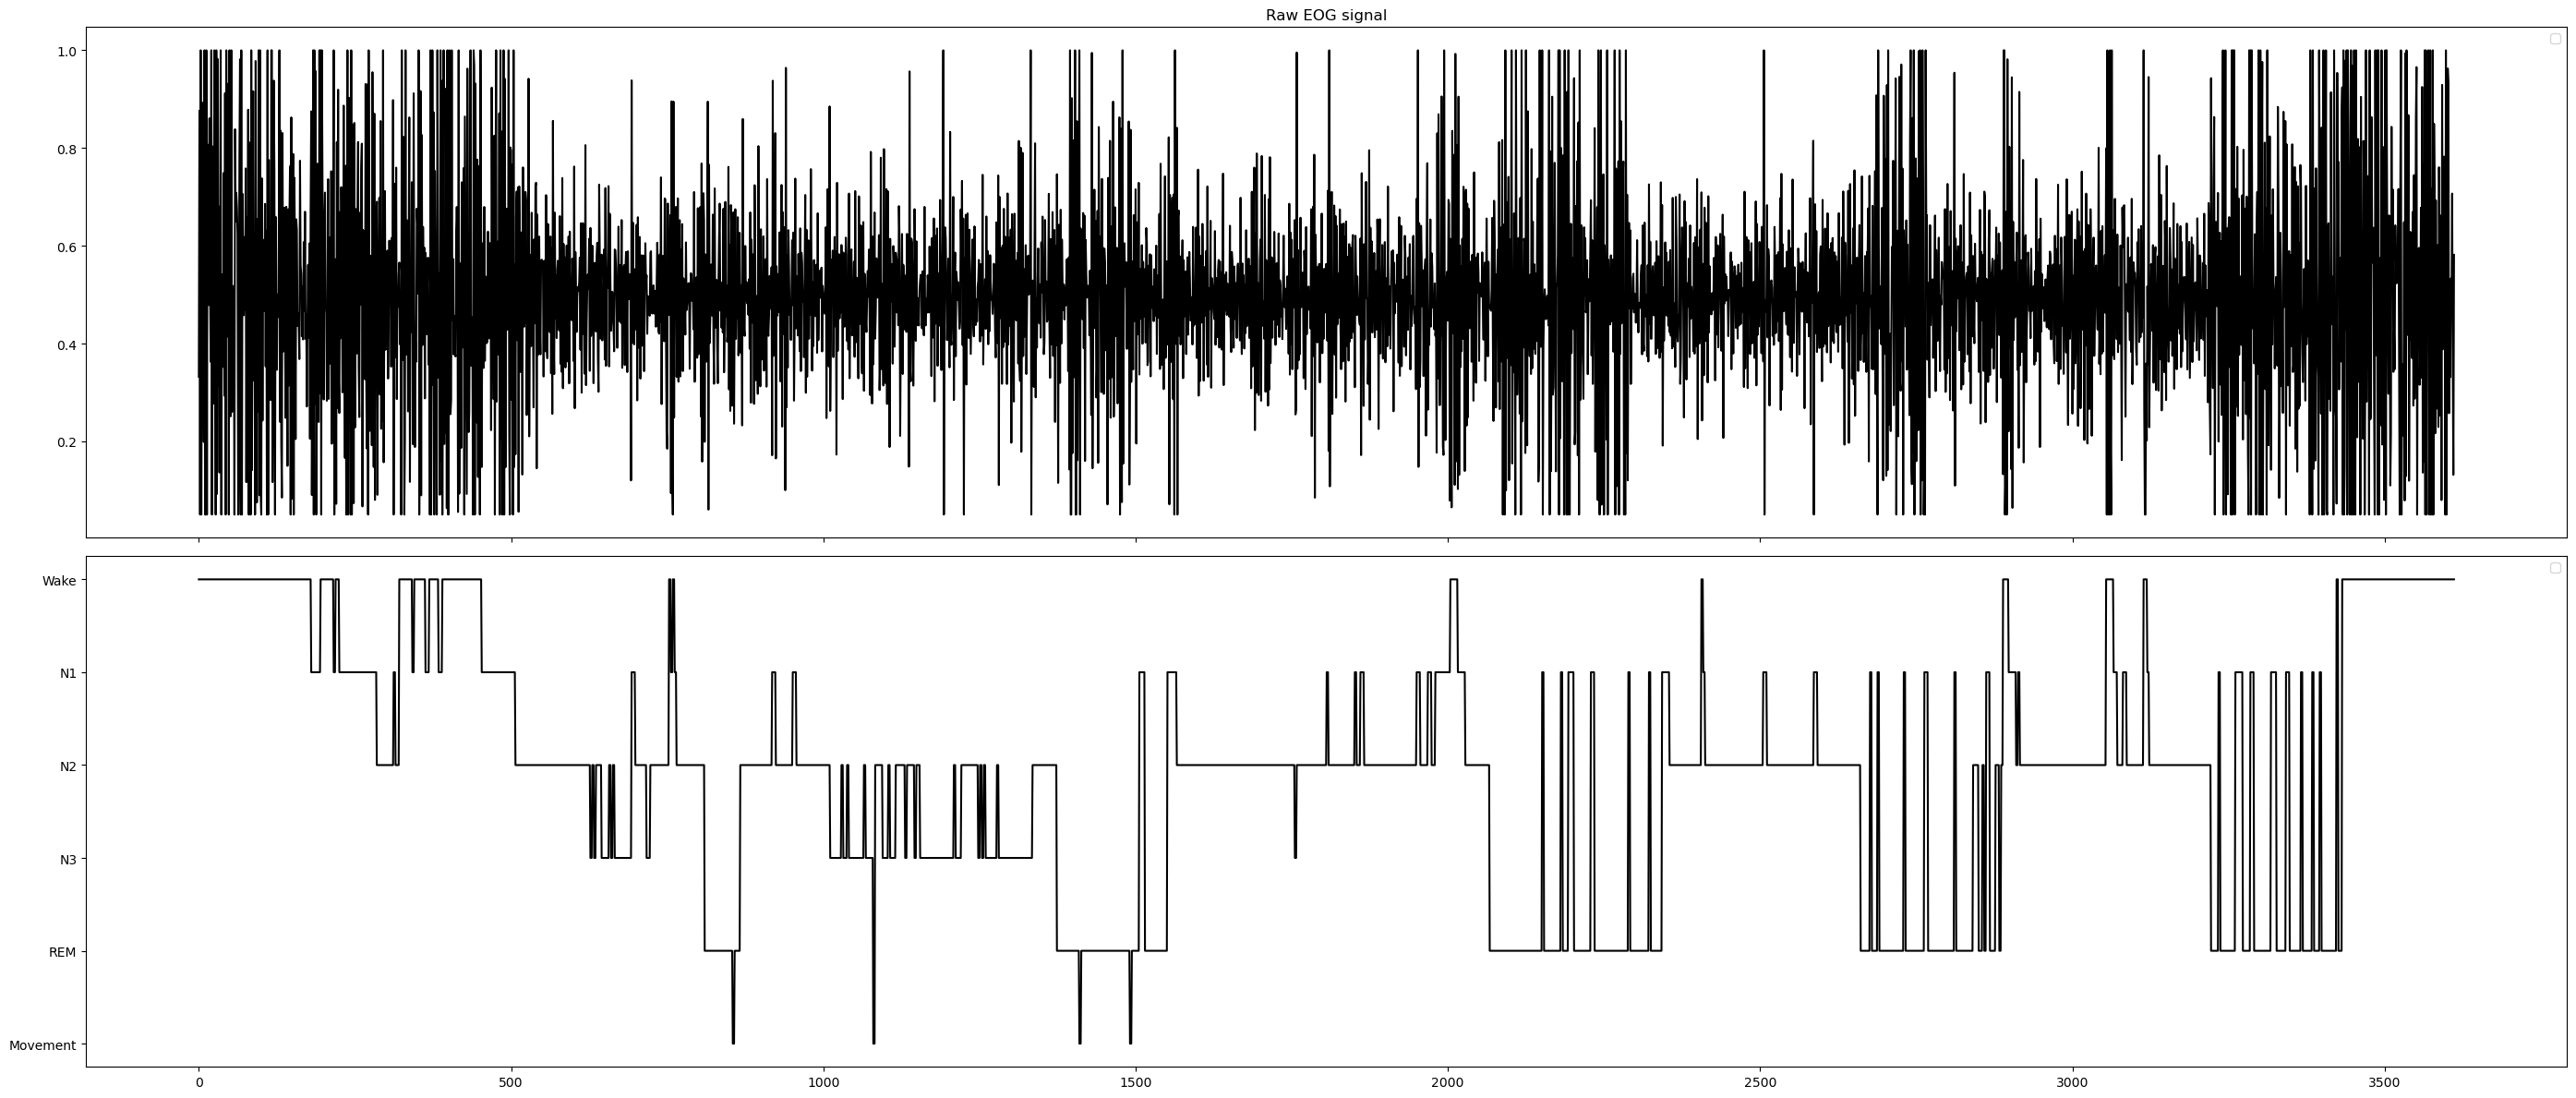

In [380]:
x = (np.arange(len(eog_norm)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(28, 12), sharex=True)

ax1.plot(x, eog_norm, label='', color='black')
ax2.plot(x, majority_scores, label='', color='black')

ax2.set_yticks(ticks=[0, 1, 2, 3, 4, 5], labels=["Wake", "N1", "N2", "N3", "REM", "Movement"])
ax2.invert_yaxis()

ax1.legend()
ax2.legend()

ax1.set_title('Raw EOG signal')
plt.tight_layout()

plt.show()

### New EOG feature

In [ ]:
def auto_correlation_slope(EOG, epoch_length, fs,min_slope_idx=1):
    print(len(EOG))
    samples = int(epoch_length * fs)
    print(samples)
    slopes = []
    for i in range(0, len(EOG) - len(EOG) % samples, samples):
        epoch = EOG[i:i + samples]
        ac_full = np.correlate(epoch, epoch, mode='full')
        center = len(ac_full) // 2
        ac = ac_full[center:]  # non-negative lags
        # normalize ac so ac[0] == 1 (helps numeric stability)
        if ac[0] == 0:
            slopes.append(np.nan)
            continue
        ac = ac / ac[0]
        peaks, _ = find_peaks(ac)
        # find first peak with index >= min_slope_idx
        valid_peaks = [p for p in peaks if p >= min_slope_idx]
        if len(valid_peaks) < 1:
            slopes.append(np.nan)
            continue
        first_peak_idx = valid_peaks[0]
        # slope between lag 0 and first_peak_idx
        slope = (ac[first_peak_idx] - ac[0]) / first_peak_idx
        slopes.append(slope)
    return np.array(slopes)

def rem_feature(EOG, epoch_length, fs,
                slope_tol=1e-6, max_inv=1e6, clip_abs=None):
    # filter (check nyquist and signal length outside)
    nyq = 0.5 * fs
    low = 0.3 / nyq
    high = 35.0 / nyq
    if not (0 < low < 1 and 0 < high < 1 and low < high):
        raise ValueError("Filter cutoff frequencies invalid for fs={}".format(fs))
    b, a = butter(4, [low, high], btype='band')
    # be careful: filtfilt requires signal length > padlen (approx 3*max(len(a),len(b)))
    if len(EOG) < 20:
        raise ValueError("Signals too short for reliable filtering.")
    EOG_f = filtfilt(b, a, EOG)

    # cross_cor_val = cross_correlation(EOG1_f, EOG2_f, epoch_length, fs, 0)
    auto_slope = auto_correlation_slope(EOG_f, epoch_length, fs)

    features = []
    for slope in auto_slope:
        if np.isnan(slope) or abs(slope) < slope_tol:
            inv = 0.0  # or np.nan depending on whether you want to keep epoch
        else:
            inv = 1.0 / slope
            # guard against absurdly large values
            if not np.isfinite(inv):
                inv = 0.0
            if max_inv is not None:
                if inv > max_inv:
                    inv = max_inv
                elif inv < -max_inv:
                    inv = -max_inv
        # keep sign of cross-corr but use normalized cc in [-1,1]
        feat = np.sign(slope) * inv
        features.append(feat)
        
    feats = np.array(features)
    if clip_abs is not None:
        feats = np.clip(feats, -clip_abs, clip_abs)
    return feats

auto_cor_feature = rem_feature(raw_eog, epoch_length, fs, slope_tol=1e-6, max_inv=1e6, clip_abs=None)

3612001
1000
[ 54.24116011  61.07661528  12.07455872 ...  19.37149959 292.535713
  77.56404647]
3612


In [ ]:
auto_cor_feature = wei_normalizing(auto_corr_feature)

C:\Users\andri\AppData\Local\Temp\ipykernel_13636\4027828092.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
C:\Users\andri\AppData\Local\Temp\ipykernel_13636\4027828092.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


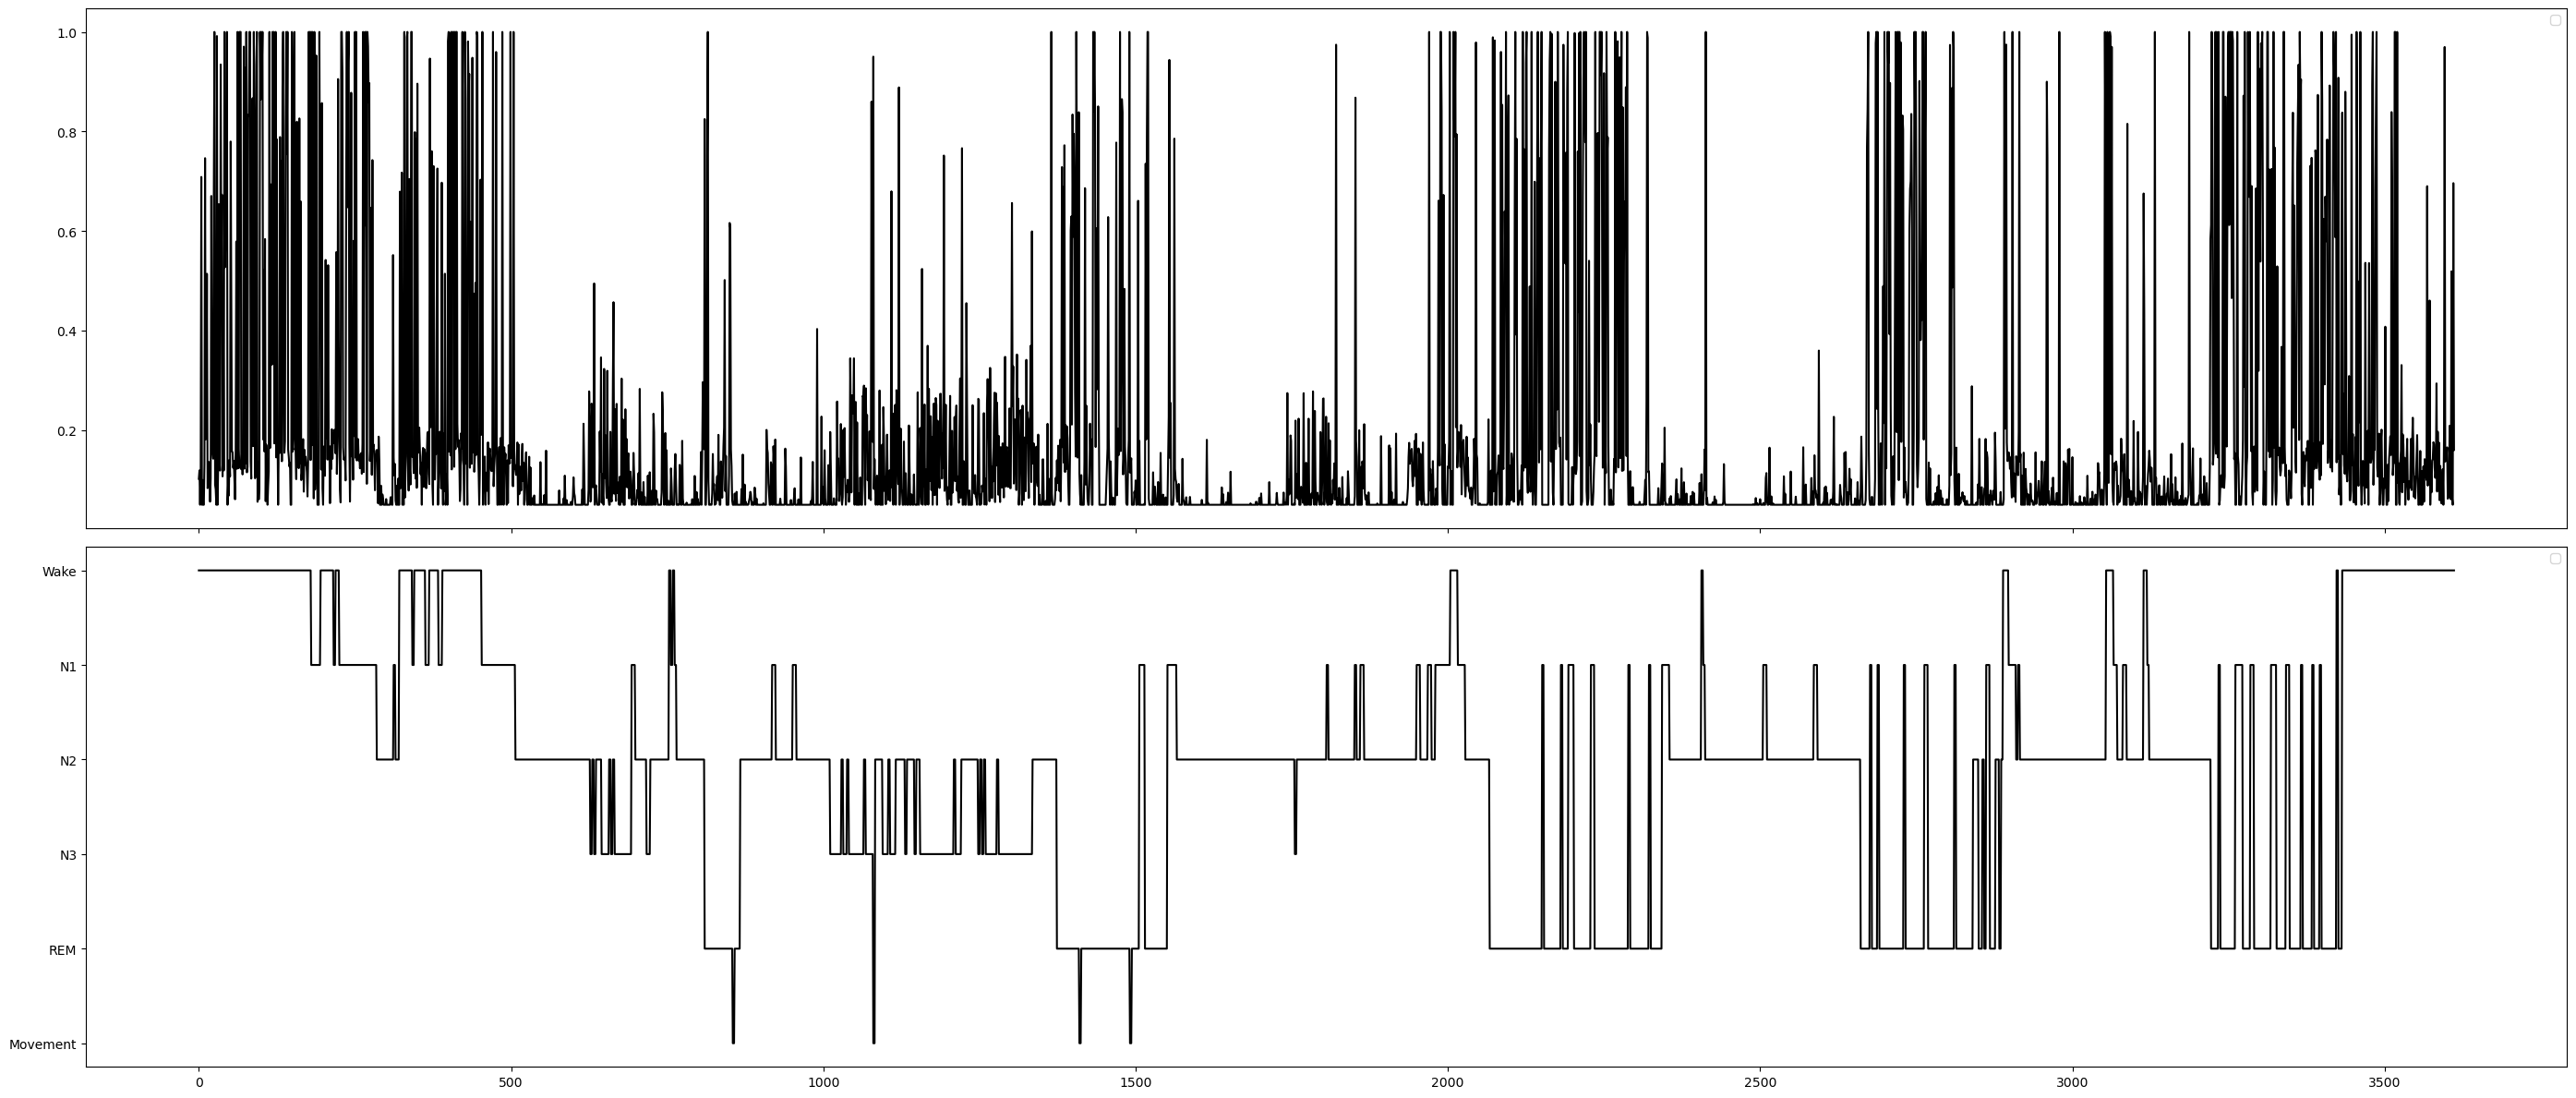

In [ ]:
x = (np.arange(len(auto_cor_feature)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(28, 12), sharex=True)

ax1.plot(x, auto_cor_feature, label='', color='black')
ax2.plot(x, majority_scores, label='', color='black')

ax2.set_yticks(ticks=[0, 1, 2, 3, 4, 5], labels=["Wake", "N1", "N2", "N3", "REM", "Movement"])
ax2.invert_yaxis()

ax1.legend()
ax2.legend()

plt.tight_layout()

plt.show()

In [398]:
if 5 in np.unique(majority_scores):
    labels = ['W', 'N1', 'N2', 'N3', 'REM', 'Movement']
    colors = ['royalblue', 'teal', 'purple', 'forestgreen', 'firebrick', 'gray']
else:
    labels = ['W', 'N1', 'N2', 'N3', 'REM']
    colors = ['royalblue', 'teal', 'purple', 'forestgreen', 'firebrick']

   state      mean       sem
0      0  0.506411  0.013214
1      1  0.502730  0.012610
2      2  0.496324  0.003268
3      3  0.501785  0.007912
4      4  0.495418  0.008114
5      5  0.513197  0.078093


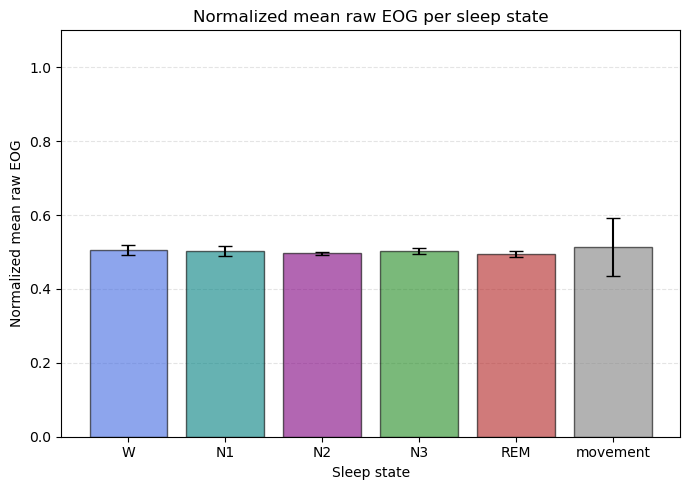

In [399]:
# smoothed_exponents, filtered_majority_scores
df = pd.DataFrame({'state': majority_scores, 'raw_eog': eog_norm})

summary = df.groupby('state')['raw_eog'].agg(['mean', 'sem']).reset_index()
print(summary)

plt.figure(figsize=(7, 5))
br = plt.bar(summary['state'], summary['mean'], yerr=summary['sem'],
        capsize=5, color=[colors[int(s)] for s in summary['state']], edgecolor='black', zorder=2, alpha=0.6)

if df["state"].isin([5]).any():
    plt.xticks([0, 1, 2, 3, 4, 5], ['W','N1','N2','N3','REM', 'movement'])
else:
    plt.xticks([0, 1, 2, 3, 4], ['W','N1','N2','N3','REM'])
plt.xlabel('Sleep state')
plt.ylabel('Normalized mean raw EOG')
plt.ylim(0, 1.1)
plt.title('Normalized mean raw EOG per sleep state')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.show()

C:\Users\andri\AppData\Local\Temp\ipykernel_13636\311548211.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


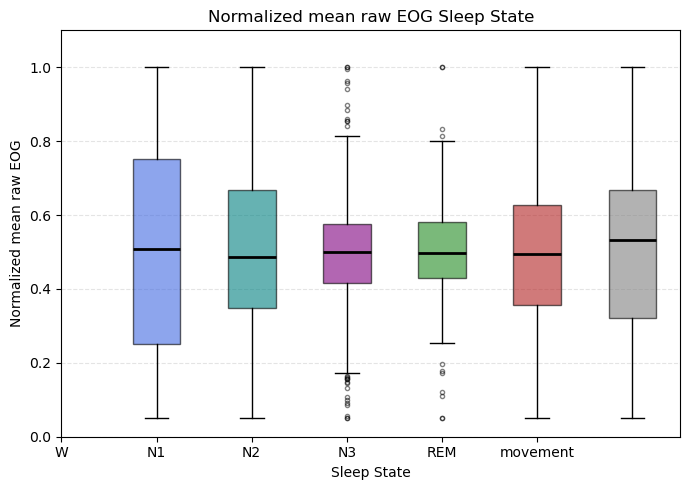

In [400]:
plt.figure(figsize=(7, 5))

# Create a boxplot
bp = plt.boxplot(
    [df.loc[df['state'] == s, 'raw_eog'] for s in range(len(labels))],
    labels=labels,
    patch_artist=True,
    boxprops=dict(facecolor='lightgray', color='black'),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=3, color='gray', alpha=0.5)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('black')

if df["state"].isin([5]).any():
    plt.xticks([0, 1, 2, 3, 4, 5], ['W','N1','N2','N3','REM', 'movement'])
else:
    plt.xticks([0, 1, 2, 3, 4], ['W','N1','N2','N3','REM'])
plt.xlabel('Sleep State')
plt.ylabel('Normalized mean raw EOG')
plt.ylim(0, 1.1)
plt.title('Normalized mean raw EOG Sleep State')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.show()

In [ ]:
# smoothed_exponents, filtered_majority_scores
df = pd.DataFrame({'state': majority_scores, 'auto_corr_feature': auto_corr_feature})

summary = df.groupby('state')['auto_corr_feature'].agg(['mean', 'sem']).reset_index()
print(summary)

plt.figure(figsize=(7, 5))
br = plt.bar(summary['state'], summary['mean'], yerr=summary['sem'],
        capsize=5, color=[colors[int(s)] for s in summary['state']], edgecolor='black', zorder=2, alpha=0.6)

if df["state"].isin([5]).any():
    plt.xticks([0, 1, 2, 3, 4, 5], ['W','N1','N2','N3','REM', 'movement'])
else:
    plt.xticks([0, 1, 2, 3, 4], ['W','N1','N2','N3','REM'])
plt.xlabel('Sleep state')
plt.ylabel('Normalized auto correlation feature')
plt.ylim(0, 1.1)
plt.title('auto correlation feature per sleep state')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))

# Create a boxplot
bp = plt.boxplot(
    [df.loc[df['state'] == s, 'auto_corr_feature'] for s in range(len(labels))],
    labels=labels,
    patch_artist=True,
    boxprops=dict(facecolor='lightgray', color='black'),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=3, color='gray', alpha=0.5)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('black')

if df["state"].isin([5]).any():
    plt.xticks([0, 1, 2, 3, 4, 5], ['W','N1','N2','N3','REM', 'movement'])
else:
    plt.xticks([0, 1, 2, 3, 4], ['W','N1','N2','N3','REM'])
plt.xlabel('Sleep State')
plt.ylabel('Normalized auto correlation feature')
plt.ylim(0, 1.1)
plt.title('Normalized auto correlation feature per Sleep State')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.signal import find_peaks, savgol_filter
import pandas as pd

def detect_large_eye_movements(signal, fs=100, amp_thresh=120, time_thresh=1.5, in_microvolts=False):
    """Return count and sample indices of large eye movements in a signal segment."""
    if not in_microvolts:
        signal = signal * 1e6  # convert from V to μV

    # if len(signal) > 5000:
    #     signal = savgol_filter(signal, 101, 3)

    peaks, _ = find_peaks(signal)
    troughs, _ = find_peaks(-signal)
    extrema = np.sort(np.concatenate((peaks, troughs)))

    event_indices = []
    for i in range(len(extrema) - 1):
        idx1, idx2 = extrema[i], extrema[i + 1]
        dt = abs(idx2 - idx1) / fs
        amp_diff = abs(signal[idx2] - signal[idx1])
        if dt <= time_thresh and amp_diff >= amp_thresh:
            event_indices.append(idx1)  # store first extrema of event

    return len(event_indices), np.array(event_indices)

def difference_variance_excluding_events(signal, event_indices, fs=100, exclude_window=0.5):
    """Compute Difference Variance after removing events ±exclude_window seconds."""
    mask = np.ones(len(signal), dtype=bool)
    samples_to_exclude = int(exclude_window * fs)

    for idx in event_indices:
        start = max(0, idx - samples_to_exclude)
        end = min(len(signal), idx + samples_to_exclude)
        mask[start:end] = False

    clean_signal = signal[mask]
    if len(clean_signal) < 2:  # avoid empty segments
        return np.nan

    diff_signal = np.diff(clean_signal)
    return np.var(diff_signal)

def process_eog_epochs(signal, fs=100, epoch_length=10, amp_thresh=120, time_thresh=1.5, exclude_window=0.5, in_microvolts=False):
    """Process EOG signal into epochs, computing large eye movement counts and difference variance."""
    samples_per_epoch = int(epoch_length * fs)
    n_epochs = len(signal) // samples_per_epoch

    counts = []
    F_sdvs = []

    for i in range(n_epochs):
        start = i * samples_per_epoch
        end = start + samples_per_epoch
        epoch = signal[start:end]

        count, indices = detect_large_eye_movements(epoch, fs=fs, amp_thresh=amp_thresh, time_thresh=time_thresh, in_microvolts=in_microvolts)
        F_sdv = difference_variance_excluding_events(epoch, indices, fs=fs, exclude_window=exclude_window)

        counts.append(count)
        F_sdvs.append(F_sdv)

    times = np.arange(n_epochs) * epoch_length
    df = pd.DataFrame({
        "epoch_start_s": times,
        "epoch_end_s": times + epoch_length,
        "large_eye_movement_count": counts,
        "diff_variance_excl_large_eye_movements": F_sdvs
    })

    return df, np.array(counts), np.array(F_sdvs)

In [ ]:
fs = 100  # Hz
epoch_length = 10  # seconds

df_epochs, counts_array, F_sdvs_array = process_eog_epochs(
    raw_eog,
    fs=fs,
    epoch_length=epoch_length,
    amp_thresh=120,
    time_thresh=1.5,
    exclude_window=0.5,
    in_microvolts=False
)

C:\Users\andri\AppData\Local\Temp\ipykernel_13636\265308868.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
C:\Users\andri\AppData\Local\Temp\ipykernel_13636\265308868.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


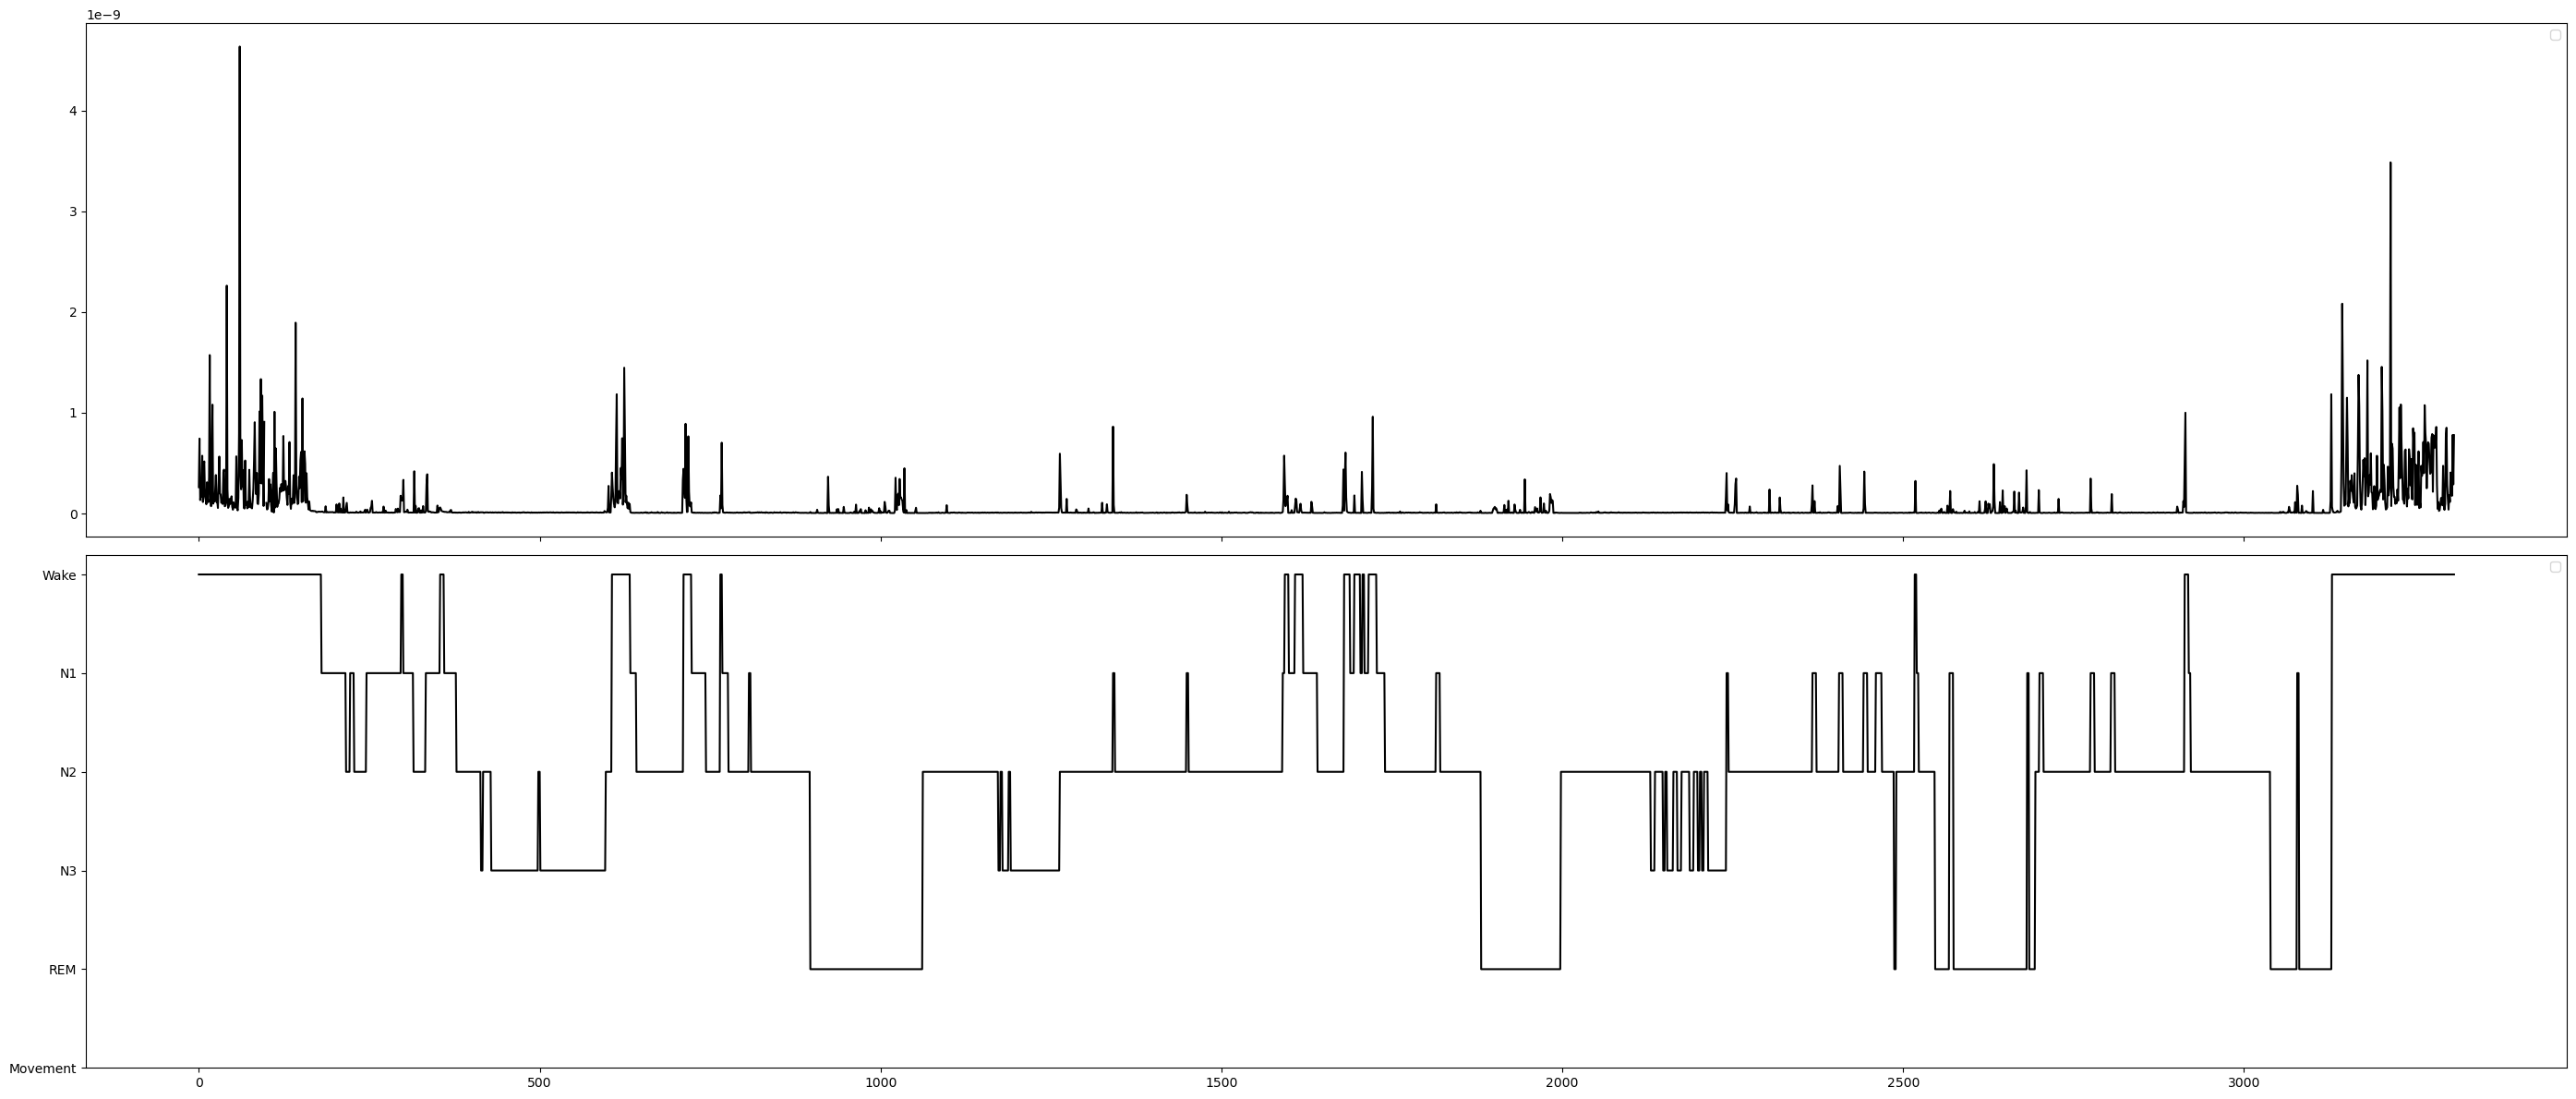

In [ ]:
x = (np.arange(len(F_sdvs_array)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(28, 12), sharex=True)

ax1.plot(x, F_sdvs_array, label='', color='black')
ax2.plot(x, majority_scores, label='', color='black')

ax2.set_yticks(ticks=[0, 1, 2, 3, 4, 5], labels=["Wake", "N1", "N2", "N3", "REM", "Movement"])
ax2.invert_yaxis()

ax1.legend()
ax2.legend()

plt.tight_layout()

plt.show()

In [ ]:
colors = ['royalblue', 'teal', 'purple', 'forestgreen', 'firebrick']
labels = ['W', 'N1', 'N2', 'N3', 'REM']

   state      mean       sem
0      0  9.220807  0.510375
1      1  0.681957  0.213407
2      2  0.075919  0.025005
3      3  0.000000  0.000000
4      4  1.439216  0.227434


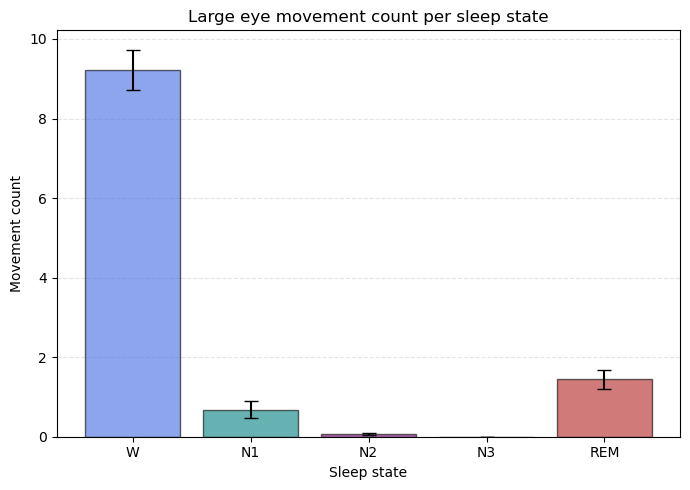

In [ ]:
# smoothed_exponents, filtered_majority_scores
df = pd.DataFrame({'state': majority_scores, 'large_eye_move_count': counts_array})

summary = df.groupby('state')['large_eye_move_count'].agg(['mean', 'sem']).reset_index()
print(summary)

plt.figure(figsize=(7, 5))
br = plt.bar(summary['state'], summary['mean'], yerr=summary['sem'],
        capsize=5, color=[colors[int(s)] for s in summary['state']], edgecolor='black', zorder=2, alpha=0.6)


plt.xticks([0, 1, 2, 3, 4], ['W','N1','N2','N3','REM'])
plt.xlabel('Sleep state')
plt.ylabel('Movement count')
plt.ylim(0)
plt.title('Large eye movement count per sleep state')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.show()

C:\Users\andri\AppData\Local\Temp\ipykernel_13636\3799308700.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


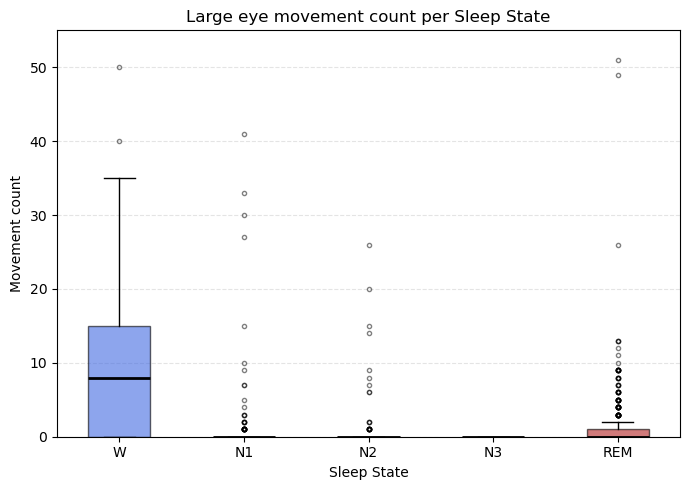

In [ ]:
plt.figure(figsize=(7, 5))

# Create a boxplot
bp = plt.boxplot(
    [df.loc[df['state'] == s, 'large_eye_move_count'] for s in range(5)],
    labels=labels,
    patch_artist=True,
    boxprops=dict(facecolor='lightgray', color='black'),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=3, color='gray', alpha=0.5)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('black')

plt.xlabel('Sleep State')
plt.ylabel('Movement count')
plt.ylim(0, 55)
plt.title('Large eye movement count per Sleep State')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.show()

   state          mean           sem
0      0  2.964205e-10  1.915052e-11
1      1  3.468727e-11  4.863049e-12
2      2  1.137619e-11  7.121057e-13
3      3  1.017078e-11  5.391883e-13
4      4  2.750229e-11  3.373458e-12


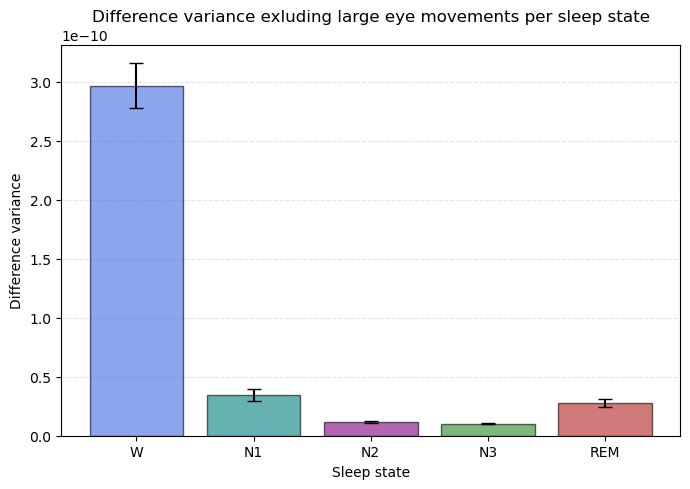

In [ ]:
# smoothed_exponents, filtered_majority_scores
df = pd.DataFrame({'state': majority_scores, 'diff_variance': F_sdvs_array})

summary = df.groupby('state')['diff_variance'].agg(['mean', 'sem']).reset_index()
print(summary)

plt.figure(figsize=(7, 5))
br = plt.bar(summary['state'], summary['mean'], yerr=summary['sem'],
        capsize=5, color=[colors[int(s)] for s in summary['state']], edgecolor='black', zorder=2, alpha=0.6)


plt.xticks([0, 1, 2, 3, 4], ['W','N1','N2','N3','REM'])
plt.xlabel('Sleep state')
plt.ylabel('Difference variance')
plt.ylim(0)
plt.title('Difference variance exluding large eye movements per sleep state')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.show()

C:\Users\andri\AppData\Local\Temp\ipykernel_13636\3724422496.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


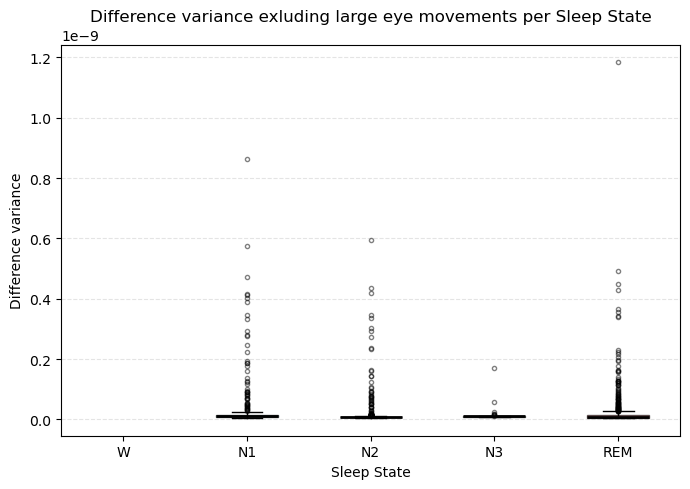

In [ ]:
plt.figure(figsize=(7, 5))

# Create a boxplot
bp = plt.boxplot(
    [df.loc[df['state'] == s, 'diff_variance'] for s in range(5)],
    labels=labels,
    patch_artist=True,
    boxprops=dict(facecolor='lightgray', color='black'),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markersize=3, color='gray', alpha=0.5)
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('black')

plt.xlabel('Sleep State')
plt.ylabel('Difference variance')
plt.title('Difference variance exluding large eye movements per Sleep State')
plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
plt.tight_layout()
plt.show()